Бизнес-задача: реализовать инструмент для классификации отзывов на негативные и позитивные

ML-задача: построить модель бинарной классификации, которая по тексту отзывов относит их к одному из двух классов - позитивному или негативному

В качестве набора данных используется корпус отзывов на рестораны Нью-Йорка с Google Maps, собранные самостоятельно в рамках работы над исследованием и ВКР. Корпус состоит из 33708 отзывов, включая тексты и метаданные. Они подходят для учебной задачи, тк уже размечены (у каждого отзыва есть количество звезд, поставленных пользователями). На этой основе можно сформировать целевую переменную. В рамках задачи отзывы с рейтинго 1-2 будут считаться негативными, а 4-5 - позитивными

Для оценки качества модели выбрана метрика **macro F1-score**. Она подхдит для бинарной классификации, когда важно корректно выделять как негативные, так и позитивные отзывы. Она позволит оценить качество модели по каждому классу, и особенно хороша при дисбалансе (негативных отзывов меньше, чем позитивных)

# EDA

### Импорт библиотек

In [42]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme()
pd.set_option('display.max_columns', None)

### Общая информация

In [4]:
path = '/content/106ready.csv'
data = pd.read_csv(path)

In [5]:
data.head()

,restic_url,name,rating,date,review,likes
0,https://maps.google.com/?cid=53790102658610108...,Chris Thompson,5,2 weeks ago,"first, zack g did a wonderful job serving our ...",NaN
1,https://maps.google.com/?cid=53790102658610108...,Wil Rampersaud,5,a month ago,"we came at around 9:30pm, and just did an appe...",NaN
2,https://maps.google.com/?cid=53790102658610108...,Courtnie Clemens,5,a month ago,excellent brunch spot! we loved the fresh-sque...,NaN
3,https://maps.google.com/?cid=53790102658610108...,Kiran Yalamanchili,5,2 weeks ago,excellent holiday decor inside warm welcoming ...,NaN
4,https://maps.google.com/?cid=53790102658610108...,Michael Jones,5,3 months ago,great food! the burger was awesome. was on the...,NaN


In [6]:
data.shape

(33708, 6)

In [7]:
data.columns

Index(['restic_url', 'name', 'rating', 'date', 'review', 'likes'], dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33708 entries, 0 to 33707
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   restic_url  33708 non-null  object 
 1   name        33708 non-null  object 
 2   rating      33708 non-null  int64  
 3   date        33708 non-null  object 
 4   review      33708 non-null  object 
 5   likes       8225 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.5+ MB


In [9]:
data.dtypes

,0
restic_url,object
name,object
rating,int64
date,object
review,object
likes,float64


Датасет содержит 33708 строк и 6 признаков, при этом для дальнейшей задачи (бинарной классификации) будут использованы сам текст и рейтинг. В датасете пропуски присутствуют только в признаке "Лайки", который в дальнейшем задействован не будет. Остальные признаки полностью заполнены

### Дубликаты

In [10]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.duplicated(subset=['restic_url', 'review']).sum()

np.int64(1)

In [11]:
data.duplicated(subset=['review']).sum()

np.int64(1)

In [13]:
data[data.duplicated(subset=['review'], keep=False)][['restic_url', 'name', 'rating', 'review']]

,restic_url,name,rating,review
33497,https://maps.google.com/?cid=13729590761682672...,keti gazdeliani,5,thank you so much for your wonderful review! w...
33498,https://maps.google.com/?cid=13729590761682672...,Irma Nikoladze,5,thank you so much for your wonderful review! w...


В датасете обнаружен один повтор текста отзыва, однако полных дубликатов строк нет. Поскольку одинаковые отзывы были оставлены разными пользователями, удалять это наблюдение не нужно

### Распределение рейтингов

In [14]:
data['rating'].value_counts().sort_index()

,count
rating,
1,2671
2,1550
3,2228
4,4586
5,22673


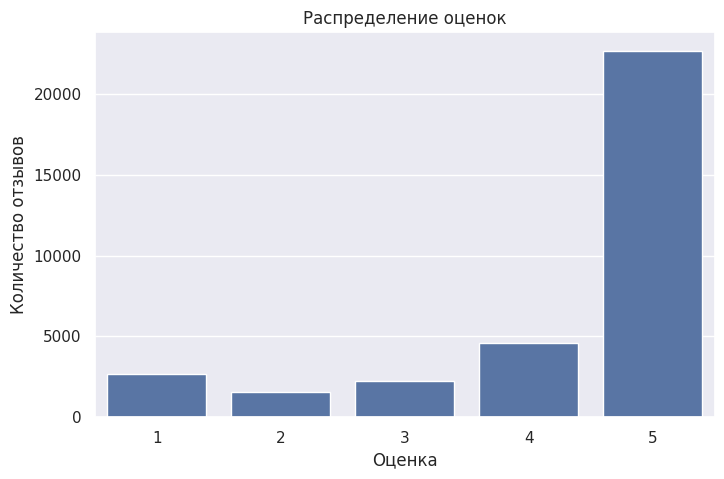

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='rating')
plt.title('Распределение оценок')
plt.xlabel('Оценка')
plt.ylabel('Количество отзывов')
plt.show()

Распределение рейтингов показало, что в датсете присутствует сильное смещение в стороны позитивных отзывов (особенно 5-звездных). При обучения модели может потребоваться использовать метод Class Weighting. Дополнительно при оценке качества модели это стоит учитывать (была выбрана метрика macro F1-score)

### Целевая переменная

In [18]:
df = data[data['rating'].isin([1, 2, 4, 5])].copy()
df['target'] = df['rating'].apply(lambda x: 1 if x in [1, 2] else 0)

In [22]:
df.groupby('rating')['target'].value_counts()

,,count
rating,target,
1,1,2671
2,1,1550
4,0,4586
5,0,22673


Отзывы с оценками 4-5 отнесены к позитивным (0), а с оценками 1-2 - к негативным (1). Отзывы с оценкой 3 - "промежуточный" класс, поэтому в рамках задачи не будут рассмотрены

In [23]:
df['target'].value_counts()

,count
target,
0,27259
1,4221


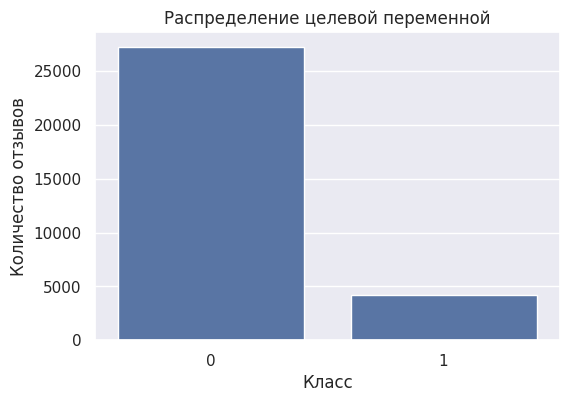

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Распределение целевой переменной')
plt.xlabel('Класс')
plt.ylabel('Количество отзывов')
plt.show()

Распределение целевой переменной подтвердило дисбаланс классов - позитивных отзывов значительно больше, чем негативных. На следующих этапах это будет учтено (см. предыдущий пункт)

### Анализ текстов

In [39]:
df['review_words'] = df['review'].astype(str).apply(lambda x: len(x.split()))

In [40]:
df[['review_words']].describe()

,review_words
count,31480.000000
mean,58.135165
std,52.219844
min,12.000000
25%,28.000000
50%,42.000000
75%,69.000000
max,776.000000


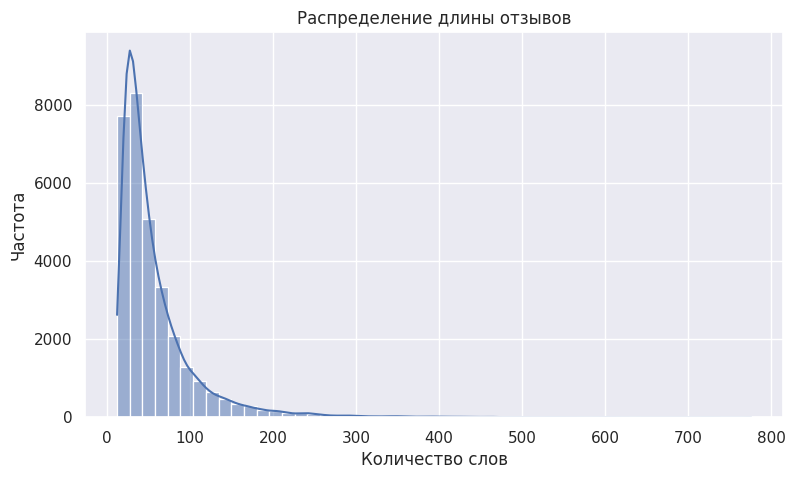

In [41]:
plt.figure(figsize=(9, 5))
sns.histplot(df['review_words'], bins=50, kde=True)
plt.title('Распределение длины отзывов')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.show()

Итоговая выборка (исключены отзывы с рейтингом 3) составила 31 480 строк. Средняя длина текста 58 слов, при этом присутствует большой разброс значений. Большая часть отзывов относительно короткая, длинные отзывы встречаются значительно реже. Следует проверить распределение длины текстов по классам

In [29]:
df.groupby('target')['review_words'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,27259.0,53.433765,45.925629,12.0,27.0,39.0,63.0,776.0
1,4221.0,88.496565,75.186030,13.0,41.0,66.0,110.0,764.0


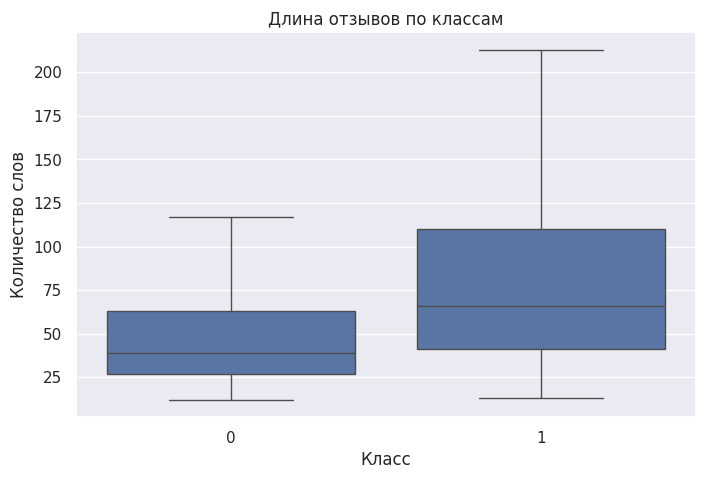

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='target', y='review_words', showfliers=False)
plt.title('Длина отзывов по классам')
plt.xlabel('Класс')
plt.ylabel('Количество слов')
plt.show()

Негативные отзывы (1) в среднем длиннее позитивных. Значит, при описании негативного опыта описание более детальное. Т.е. для задачи это становится информативным признаком для модели

### Общий вывод

1) Сформулирована задача бинарной классификации для определения негативных и позитивных отзывов на рестораны. Для этого будет использован датасет с отзывами из Google Maps, который содержит тексты и рейтинги, а также другие метаданные, которые использоваться не будут

2) В качетве метрики будет использоваться macro F1-score, тк важно веделять оба класса

3) Распределение целевой переменной показало дисбаланс - позитивных отзывов значительно больше, что важно учитывать как при обучении модели, так и при оценке качества

4) В качестве основного информативного признака рассмотрен текст отзывов. EDA показал, что длина текста может рассматриваться как дополнительный признак, тк негативные отзывы в среднем более детальные